# Customer Segmentation using RFM Analysis

## Data Cleaning, Feature Engineering, and Exploratory Data Analysis

This notebook prepares the online retail dataset for customer segmentation.

The analysis includes:
- data cleaning
- total spend calculation
- RFM feature engineering
- exploratory data analysis of Recency, Frequency, and Monetary
- outlier handling using log transformation

These steps ensure the data is suitable for clustering and help identify customer behaviour patterns for targeted marketing.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_excel("Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [13]:
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove returns (negative quantity)
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

df.shape

(397884, 9)

### Data Cleaning

Records with missing CustomerID values were removed, as these cannot be assigned to specific customers.

Transactions with negative quantities were excluded since they represent product returns rather than purchases.

Additionally, records with zero or negative UnitPrice were removed to ensure accurate calculation of customer spending.

In [4]:
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Set reference date (latest date in dataset)
import datetime as dt
reference_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

NameError: name 'pd' is not defined

### RFM Feature Engineering

RFM (Recency, Frequency, Monetary) analysis was used to summarise customer behaviour.

- Recency measures how recently a customer made a purchase.
- Frequency measures how often a customer makes purchases.
- Monetary measures how much money a customer has spent.

These metrics are widely used in marketing to segment customers based on their purchasing behaviour.

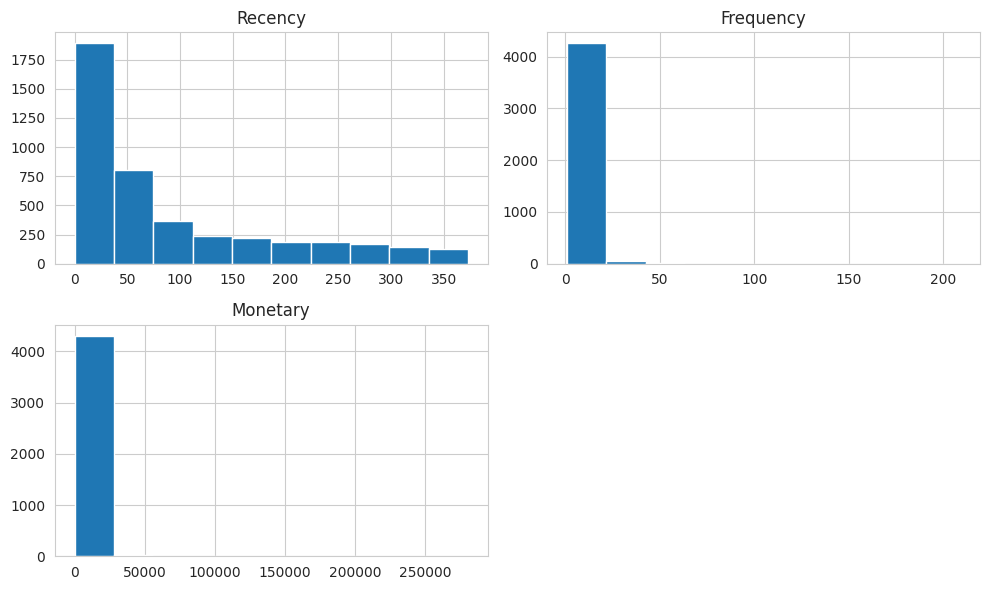

In [ ]:
# Histograms for RFM

rfm.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

The imbalance in customer spending suggests that a small proportion of customers contribute significantly to total revenue. This highlights the importance of identifying high-value customer segments for targeted marketing.

### Interpretation of RFM Distributions

The histograms show that all three RFM variables are highly skewed.

Most customers have low frequency and low monetary values, while a small number of customers contribute significantly higher values.

This indicates that customer purchasing behaviour is uneven, with a minority of high-value customers generating a large portion of revenue.

Such skewness suggests the presence of outliers, which need to be handled before applying clustering models.

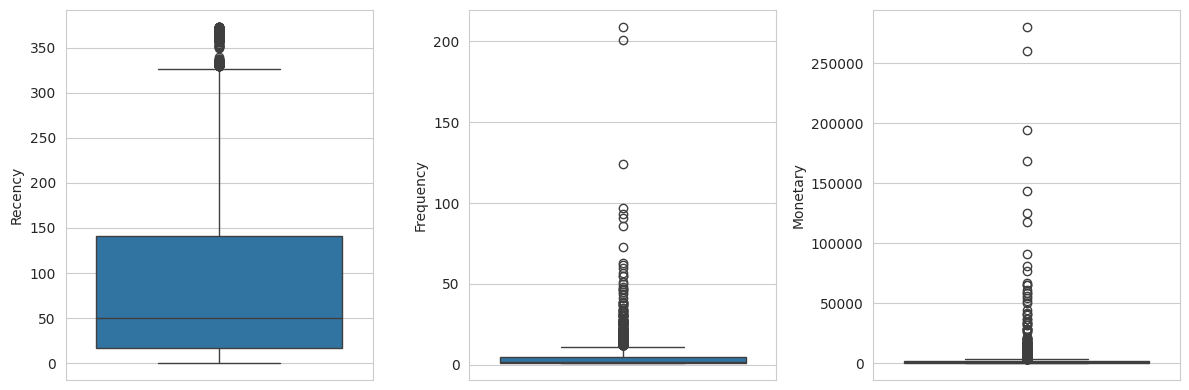

In [ ]:
# Boxplots for RFM variables

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])

plt.tight_layout()
plt.show()

### Analysis of Outliers

The boxplots clearly show the presence of extreme outliers in the RFM variables.

In particular, Frequency and Monetary display significant high-value outliers, indicating that a small number of customers make frequent purchases or spend large amounts.

These extreme values can negatively affect clustering algorithms such as K-Means, as they can dominate distance calculations and distort cluster formation.

Therefore, it is necessary to handle these outliers before proceeding to modelling.

In [ ]:
# Apply log transformation

rfm_log = np.log1p(rfm)

rfm_log.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,5.786897,0.693147,11.253955
12347.0,0.693147,2.079442,8.368925
12348.0,4.317488,1.609438,7.494564
12349.0,2.944439,0.693147,7.472245
12350.0,5.736572,0.693147,5.815324


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

ModuleNotFoundError: No module named 'sklearn'

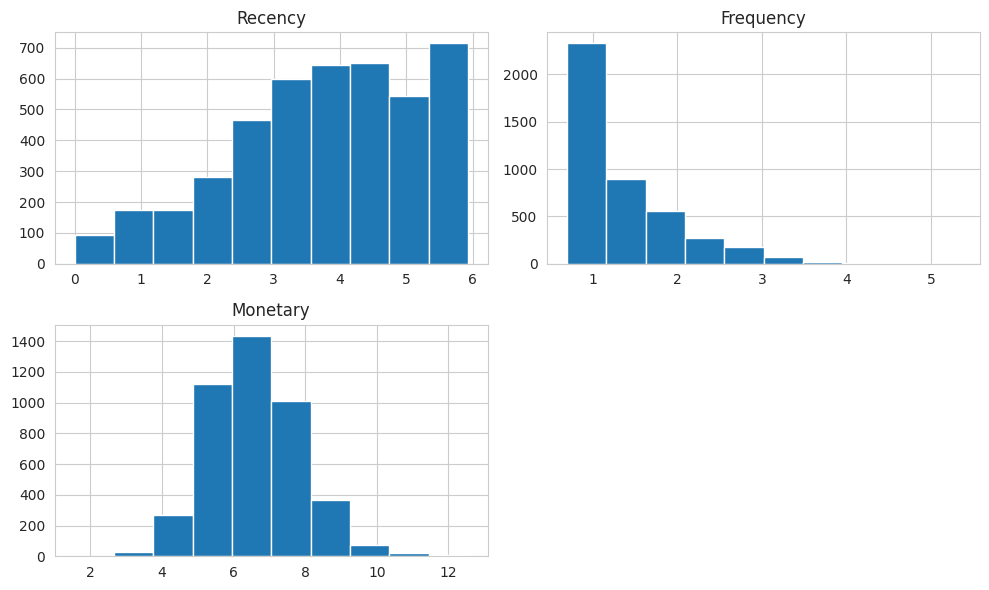

In [ ]:
# Histograms after log transformation

rfm_log.hist(figsize=(10,6))
plt.tight_layout()
plt.show()

### Effect of Log Transformation

The RFM variables were highly skewed due to the presence of extreme outliers.

To address this, a log transformation was applied using the log1p function, which reduces the impact of large values.

After transformation, the distributions become more balanced and less skewed, making the data more suitable for clustering algorithms such as K-Means.

This step improves the quality and reliability of the customer segmentation results.

### Conclusion

This analysis prepared the dataset for customer segmentation by performing data cleaning, feature engineering, and exploratory data analysis.

RFM metrics provided a meaningful summary of customer behaviour, while visualisation revealed significant skewness and outliers.

Applying a log transformation improved the data distribution, making it more suitable for clustering.

These steps ensure that the dataset is well-prepared for machine learning models to generate accurate and meaningful customer segments.